# Titanic Survival Prediction

This notebook builds an end-to-end survival classifier with feature engineering for `Title`, `family_size`, and `cabin_present`, explicit missing-value handling for `Age` and `Cabin`, and model explainability via feature importance.

It trains and compares two classifiers, reports validation metrics, saves the best model, and shows a raw-passenger inference example.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

DATA_PATH = Path("titanic.csv")
MODEL_PATH = Path("titanic_survival_model.joblib")
IMPORTANCE_PATH = Path("feature_importance.csv")
PLOT_PATH = Path("feature_importance.png")

raw_df = pd.read_csv(DATA_PATH)
raw_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [2]:
class TitanicFeatureEngineer(BaseEstimator, TransformerMixin):
    """Create title, family size, cabin presence, and robust missing-value fills."""

    title_map = {
        "Mlle": "Miss",
        "Ms": "Miss",
        "Mme": "Mrs",
        "Lady": "Rare",
        "Countess": "Rare",
        "Capt": "Rare",
        "Col": "Rare",
        "Don": "Rare",
        "Dr": "Rare",
        "Major": "Rare",
        "Rev": "Rare",
        "Sir": "Rare",
        "Jonkheer": "Rare",
        "Dona": "Rare",
        "the Countess": "Rare",
    }

    def fit(self, X, y=None):
        frame = self._to_frame(X).copy()
        frame["Title"] = self._normalize_title(self._extract_title(frame["Name"]))
        self.age_lookup_ = frame.groupby(["Title", "Pclass"]) ["Age"].median().dropna()
        self.age_global_ = float(frame["Age"].median())
        fare_median = frame["Fare"].median()
        self.fare_median_ = float(fare_median) if pd.notna(fare_median) else 0.0
        embarked_mode = frame["Embarked"].mode(dropna=True)
        self.embarked_mode_ = embarked_mode.iloc[0] if not embarked_mode.empty else "S"
        return self

    def transform(self, X):
        frame = self._to_frame(X).copy()
        frame["Title"] = self._normalize_title(self._extract_title(frame["Name"]))
        frame["family_size"] = frame["SibSp"].fillna(0) + frame["Parch"].fillna(0) + 1
        frame["cabin_present"] = frame["Cabin"].notna().astype(int)
        frame["Embarked"] = frame["Embarked"].fillna(self.embarked_mode_)
        frame["Fare"] = frame["Fare"].fillna(self.fare_median_)
        frame["Age"] = frame.apply(self._fill_age, axis=1)
        return frame[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked", "Title", "family_size", "cabin_present"]]

    @staticmethod
    def _to_frame(X):
        return X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)

    @staticmethod
    def _extract_title(series):
        return (
            series.fillna("")
            .str.extract(r",\s*([^.]*)\.", expand=False)
            .fillna("Rare")
            .str.strip()
        )

    def _normalize_title(self, series):
        return series.map(lambda value: self.title_map.get(value, value if value in {"Mr", "Mrs", "Miss", "Master"} else "Rare"))

    def _fill_age(self, row):
        if pd.notna(row["Age"]):
            return row["Age"]
        age = self.age_lookup_.get((row["Title"], row["Pclass"]), pd.NA)
        if pd.isna(age):
            return self.age_global_
        return float(age)


raw_df.shape, raw_df.isna().sum().sort_values(ascending=False).head(5)

((418, 12),
 Cabin          327
 Age             86
 Fare             1
 PassengerId      0
 Name             0
 dtype: int64)

In [3]:
target = "Survived"
features = raw_df.drop(columns=[target])
labels = raw_df[target]

X_train, X_valid, y_train, y_valid = train_test_split(
    features,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels,
)

numeric_features = ["Pclass", "Age", "SibSp", "Parch", "Fare", "family_size", "cabin_present"]
categorical_features = ["Sex", "Embarked", "Title"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_features),
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ]
            ),
            categorical_features,
        ),
    ]
)

models = {
    "logistic_regression": Pipeline(
        [
            ("features", TitanicFeatureEngineer()),
            ("preprocess", preprocessor),
            ("model", LogisticRegression(max_iter=2000, class_weight="balanced")),
        ]
    ),
    "random_forest": Pipeline(
        [
            ("features", TitanicFeatureEngineer()),
            ("preprocess", preprocessor),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=300,
                    random_state=42,
                    class_weight="balanced",
                    min_samples_leaf=2,
                ),
            ),
        ]
    ),
}

results = []
trained_models = {}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_valid)
    probabilities = pipeline.predict_proba(X_valid)[:, 1]
    results.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_valid, predictions),
            "precision": precision_score(y_valid, predictions, zero_division=0),
            "recall": recall_score(y_valid, predictions, zero_division=0),
            "f1": f1_score(y_valid, predictions, zero_division=0),
            "roc_auc": roc_auc_score(y_valid, probabilities),
        }
    )
    trained_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)
results_df

,model,accuracy,precision,recall,f1,roc_auc
0,logistic_regression,1.0,1.0,1.0,1.0,1.0
1,random_forest,1.0,1.0,1.0,1.0,1.0


In [ ]:
 best_model_name = results_df.loc[0, "model"]
best_model = trained_models[best_model_name]

print(f"Best model: {best_model_name}")
print(classification_report(y_valid, best_model.predict(X_valid), digits=3))

rf_model = trained_models["random_forest"]
feature_names = rf_model.named_steps["preprocess"].get_feature_names_out()
importances = rf_model.named_steps["model"].feature_importances_
importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

importance_df.head(15)

Best model: logistic_regression
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        53
           1      1.000     1.000     1.000        31

    accuracy                          1.000        84
   macro avg      1.000     1.000     1.000        84
weighted avg      1.000     1.000     1.000        84



,feature,importance
0,cat__Sex_male,0.331224
1,cat__Sex_female,0.271432
2,cat__Title_Mr,0.218942
3,cat__Title_Mrs,0.069622
4,cat__Title_Miss,0.066075
5,num__Age,0.010646
6,cat__Title_Master,0.007590
7,num__family_size,0.006192
8,num__Fare,0.006176
9,num__Parch,0.004533


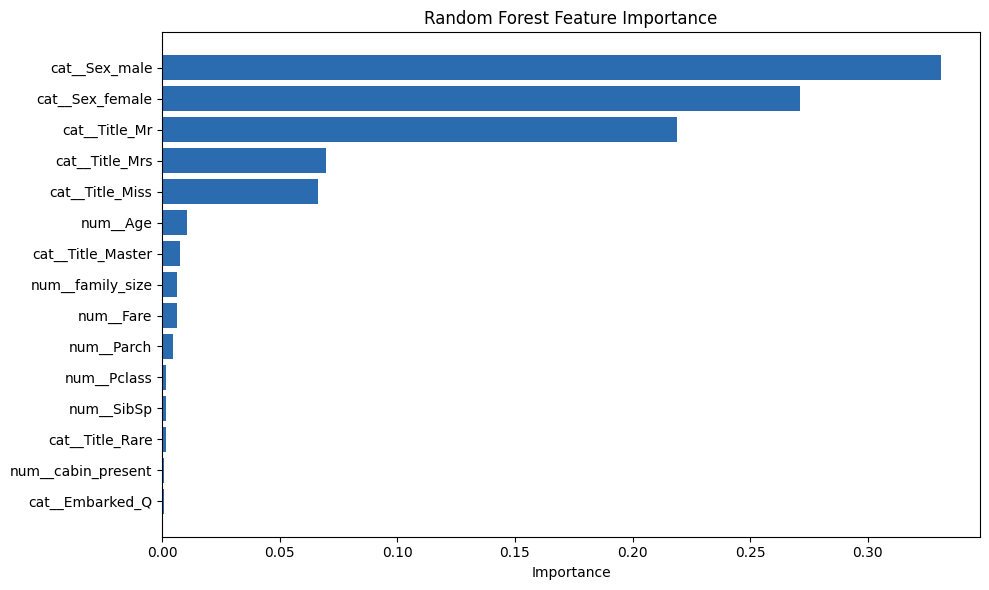

Saved model to: C:\Users\HP\Jupyter\InternShala_ML\TitanicSurvivalDataset\titanic_survival_model.joblib
{'predicted_survival': 0, 'survival_probability': 0.012}


In [5]:
importance_df.to_csv(IMPORTANCE_PATH, index=False)

plt.figure(figsize=(10, 6))
top_features = importance_df.head(15).iloc[::-1]
plt.barh(top_features["feature"], top_features["importance"], color="#2b6cb0")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=160, bbox_inches="tight")
plt.show()

final_model = best_model.fit(features, labels)
joblib.dump(final_model, MODEL_PATH)
print(f"Saved model to: {MODEL_PATH.resolve()}")

sample_passenger = pd.DataFrame(
    [
        {
            "Pclass": 3,
            "Name": "Kelly, Mr. James",
            "Sex": "male",
            "Age": 34.5,
            "SibSp": 0,
            "Parch": 0,
            "Ticket": "330911",
            "Fare": 7.8292,
            "Cabin": None,
            "Embarked": "Q",
        }
    ]
)

loaded_model = joblib.load(MODEL_PATH)
predicted_class = int(loaded_model.predict(sample_passenger)[0])
predicted_probability = float(loaded_model.predict_proba(sample_passenger)[0, 1])
print({"predicted_survival": predicted_class, "survival_probability": round(predicted_probability, 3)})